## Day 26 - Deep Learning 3, transformers and large language models

The mathematical object within Claude, ChatGPT, etc are very large neural networks built from transformer blocks, and trained to predict tokens.

So we still have everything we have learnt so far which follows:

$$
X
\rightarrow
\text{layers}
\rightarrow
\hat y
\rightarrow
J
\rightarrow
\text{backpropagation}
$$

But now we also have transformers, in particular attention

### From Sequences to attention

Data can almost always create sequences, I am writing specific words one after the other, there are spectra as a function of wavelength and light curves as a function of time.

And before transformers, there were RNNs which reads data as $x_1 \rightarrow x_2 \rightarrow x_3 \rightarrow \ldots$ while carrying a hidden state, it reads from left to right.

This means that outputs, for an RNN, at a time $t$ depend on the previous state as shown:

$$
y^{(t)}
=
A\left(
X_tW_x+b+y^{(t-1)}W_y
\right)
$$

Where the $y^{(t-1)}W_y$ is the RNN's memory and is the only thing added to an ordinary neural network.

The same weights are reused at every sequence step and so this gives the RNN a memory of the previous steps.

However, there are a few problems relating to this
- As each step repeatedly multiplies information through $W_y$ and passes it through activations, the old information can fade
- gradients during training can also vanish or explode
- This is hard to parallelise (allow multiple computers to work on it at once) as token $t$ depends on token $t-1$

**Transformers** do something different, they allow every token to look directly at every other token, so instead of the left to right sequence we had before, now we can look at it as:

$$x_1 \leftrightarrow x_4, \quad x_2 \leftrightarrow x_7, \quad x_3 \leftrightarrow x_{100}$$

The token does not have to wait for information to propagate sequentially through many intermediate states. Instead, with attention, it can directly look across the sequence and determine which other positions are most relevant to it.

### Tokens 

Language models do not predict words, but tokens

> A token can be a word, a piece of a word, punctuation, whitespace, or some other learned text fragment

What a token splits a sentence into just depends on the tokeniser.


Let's look at a neural network, this first layer will map each token id to an embedding vector. The model will no longer see words, it will just see points in a high dimensional vector space. 

The goal is for semantic and syntactic structure to become geometry

This is an example of representation learning.

In [3]:
# A tiny, deliberately silly tokenizer example.
# Real tokenizers are learned from large corpora; this is just to fix ideas.

text = "black holes merge after stars evolve"
print(text.split())

vocabulary = {token: i for i, token in enumerate(sorted(set(text.split())))}
print(vocabulary)

ids = [vocabulary[token] for token in text.split()]
print(ids)

['black', 'holes', 'merge', 'after', 'stars', 'evolve']
{'after': 0, 'black': 1, 'evolve': 2, 'holes': 3, 'merge': 4, 'stars': 5}
[1, 3, 4, 0, 5, 2]


### Self attention

Each token asks, "which other tokens in this same sequence should I pay attention to?"

For each token embedding $x_i$, the model constructs 3 vectors:

$$
\mathbf q_i=W_Q\mathbf x_i,
\qquad
\mathbf k_i=W_K\mathbf x_i,
\qquad
\mathbf v_i=W_V\mathbf x_i
$$

The $W's$ are learned weight matrices, the same as every other neural network weight matrix we have seen.

We can call these queries, keys and values.
- The query is what a token is looking for
- The keys say what each token can offer
- The values contain the infromation that will be mixed together

> Example: If we image the token 'merge', its query may be useful for identifying which objects are doing the merging. Then the key belonging to 'holes' may match the query quite strongly. If this is true, then the model will take more of a value vector belonging to holes when constructing the new representation of 'merge'.

##### But which token matters?

For token $i$, the attention paid to token $j$ is proportional to the dot product between $q_i$ and $k_j$:


$$\mathrm{score}_{ij} = \frac{\mathbf{q}_i \cdot \mathbf{k}_j}{\sqrt{d_k}}.$$

If the dot product is large, token $j$'s key aligns strongly with what token $i$'s query is looking for.

We divide by $\sqrt{d_k}$ because as vectors become high dimensional, the dot products become very large in magnitude. Hence dividing by this allows us to scale the scores which is numerically more manageable.

Applying a softmax to convert the scores into weights as such:

$$\alpha_{ij} = \frac{\exp(\mathrm{score}_{ij})}{\sum_j \exp(\mathrm{score}_{ij})}.$$

This reminds me of the boltzmann distribution. And it allows us to see how much attention we should give to eaech token.

> softmax is a function that takes a set of numbers and turns them into positive weights that add up to 1.

The output for token $i$ is a weighted sum of the value vectors:

$$\mathbf{z}_i = \sum_j \alpha_{ij}\mathbf{v}_j.$$

The new representation of token $i$, becomes a weighted mixture of information from other tokens

The complete equation using matrix form is:

$$\mathrm{Attention}(Q,K,V) = \mathrm{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V.$$

This is the heart of the transformer. It is just linear algebra, learned weights, softmax and backpropagation



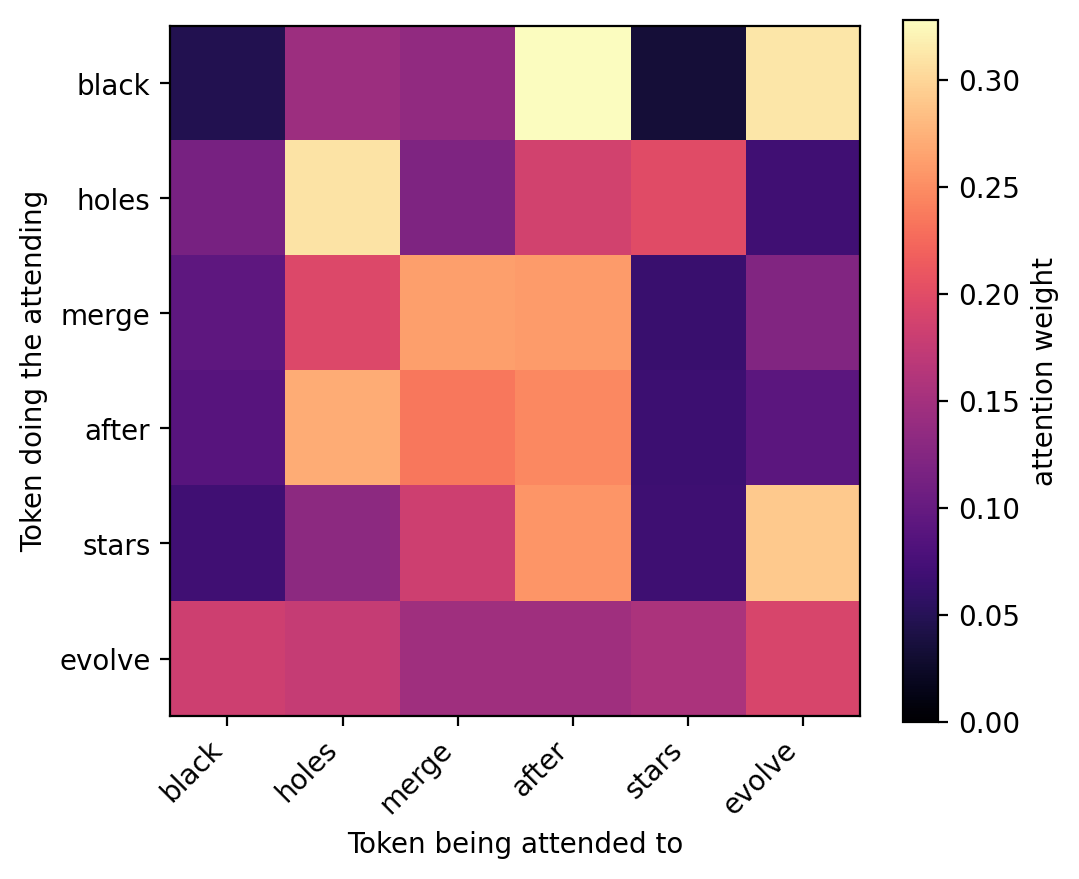

In [4]:
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format='retina'

rng = np.random.default_rng(42)

tokens = ["black", "holes", "merge", "after", "stars", "evolve"]
n_tokens = len(tokens)
d_model = 8
d_k = 8

# Fake embeddings and fake learned matrices.
X = rng.normal(size=(n_tokens, d_model))
Wq = rng.normal(scale=0.4, size=(d_model, d_k))
Wk = rng.normal(scale=0.4, size=(d_model, d_k))
Wv = rng.normal(scale=0.4, size=(d_model, d_k))

Q = X @ Wq
K = X @ Wk
V = X @ Wv

scores = Q @ K.T / np.sqrt(d_k)
attention = np.exp(scores - scores.max(axis=1, keepdims=True))
attention = attention / attention.sum(axis=1, keepdims=True)
Z = attention @ V

fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(attention, cmap="magma", vmin=0, vmax=attention.max())
ax.set_xticks(range(n_tokens), tokens, rotation=45, ha="right")
ax.set_yticks(range(n_tokens), tokens)
ax.set_xlabel("Token being attended to")
ax.set_ylabel("Token doing the attending")
fig.colorbar(im, ax=ax, label="attention weight")
plt.tight_layout()
plt.show()

This plot is an $N_{\text{tokens}} \times N_{\text{tokens}}$ matrix, where each row represents the token doing the attending and each column represents the token being attended to.

### Multi-head attention

So we were talking about 1 attention operation, but this is quite limited in a way that we may want to look for different kinds of relationships simultaneously.So a transformer uses multihead attention. Here, several attention maps are computed in parallel, each with its own learned $W_Q$, $W_K$ and $W_V$ matrices.

The outputs from all the heads are concatenated and then passed through another learned linear layer where it combined the heads into a useful final representation.

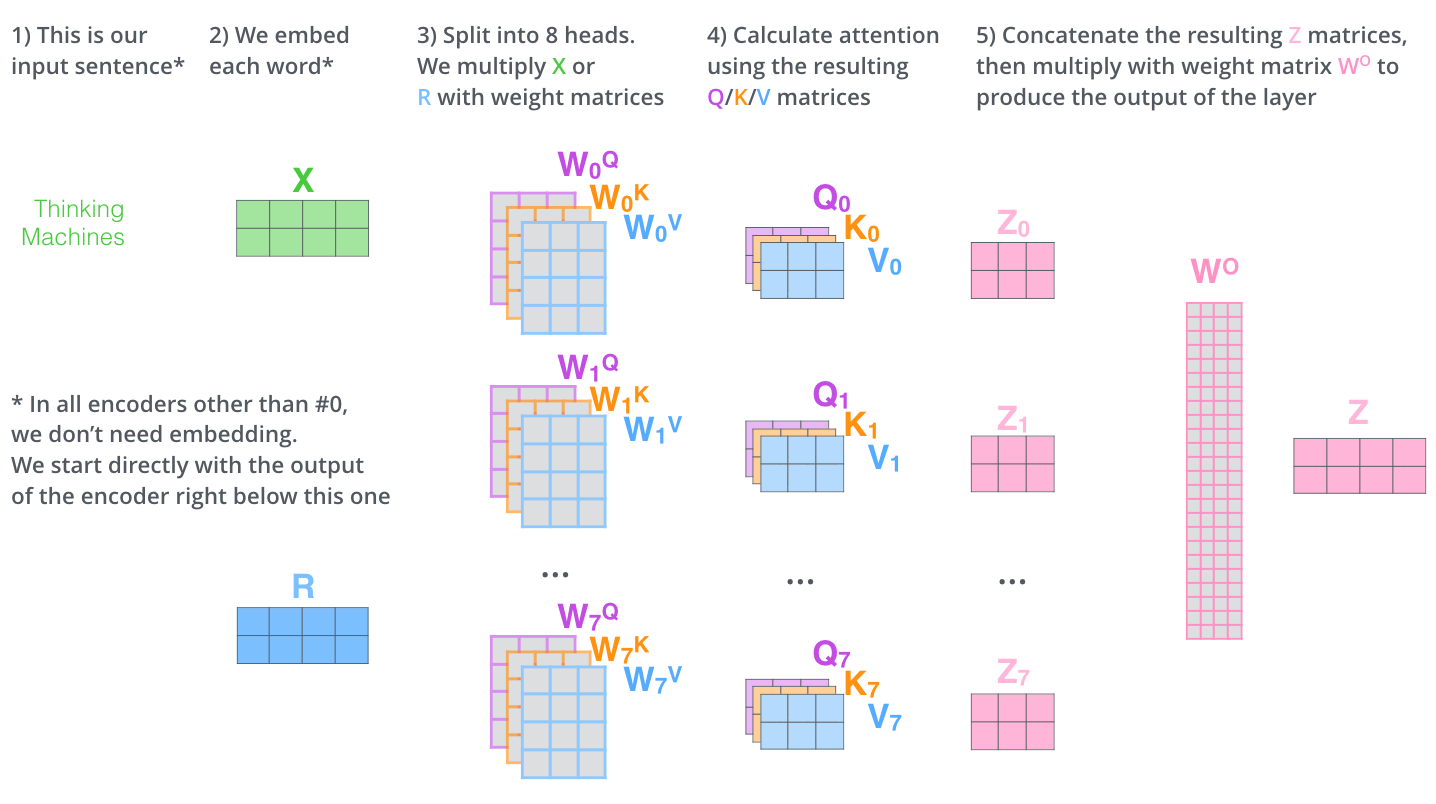



We can think of this like observing the same astronomical object through several filters, which can reveal different aspects of its spectral energy distribution.

### Positional encodings

Self attention by itself doesn't know the order of the tokens. If we permute the input tokens, the same pairwise dot products are still available, just permuted. So basically, attention knows which tokens are related, but not which one came first, second, etc unless we explicitly give it positional information.

We know that order matters too as 'stars eat planets' is not the same as 'planets eat stars'

> This is kind of where RNNs have an advantage as order is built into it.

Transformers hence add positional information to token embeddings. Where the original paper used sinusoidal positional encodings:

$$\mathrm{PE}_{(\mathrm{pos},2i)} = \sin\left(\frac{\mathrm{pos}}{10000^{2i/d_{\rm model}}}\right),$$

$$\mathrm{PE}_{(\mathrm{pos},2i+1)} = \cos\left(\frac{\mathrm{pos}}{10000^{2i/d_{\rm model}}}\right).$$

- Where pos is the token in the sequence: 0,1,2,..
- $i$ is the pair of embedding dimensions that we are filling
- $d_{\text{model}}$ is the embedding size

Each token position therefore gets a different pattern of sine and cosine values across the embedding dimensions. Different dimensions vary at different rates with position, so together they form a unique positional "fingerprint". This positional encoding is added to the token embedding, allowing the transformer to distinguish token order and relative position within the sequence.


### GPT's (Generative pre-trained transformer)

Given tokens, $x_1, x_2, \ldots, x_t$ GPT tries to predict:

$$
p(x_{t+1}\mid x_1,x_2,\ldots,x_t)
$$

Which is quite a simple task of predicting which token is most likely to come next, given that we have everything so far.

A GPT is autoregressive, meaning it generates one token, adds that token to the sequence and then predicts again.

However, if we give the model 'black hole merge' if the network can look at the whole sequence while predicting 'merge' it may just look at the answer which is cheating. Hence, GPT uses a causal mask, where token $i$ may only attend to $j \leq i$, where future tokens are hidden.

Mathematically, we add $- \infty$ to the forbidden attention scores before the softmax:

$$\mathrm{score}_{ij} = -\infty \quad \mathrm{for}\quad j>i.$$

After the softmax, the weights become zero.

### Training an LLM

This happens through a few stages such as:

1. Pretraining where we train on a huge corpus to predict the next token. This is where most of the computing goes
2. Instruction tuning where we fine tune on examples of useful instructions and answers
3. Preference optimisation where we tune the model so that humans or another model standing in for humans prefer its answers
4. Tool use and retrieval where we connect the model to search, code execution, documents, etc

So the base model learns a language and at the later stages it behaves like an assistant.

### Why do LLMs hallucinate?

As an LLM model has seen many paper titles, author lists, BibTeX entries, and arXiv like strings, it can generate something that looks exactly like a citation. However, looking like one and being one are different. 

Hence, LLMs shoudl only be used for acceleration not authority.

So we can use LLMs for:
- Explaining a method at a different level
- Drafting code that you will test
- Summarising papers you provide
- Translating between notation systems
- Brainstorm checks, edge cases 

WHAT WE SHOULDN'T USE THEM FOR:
- Citing papers without verifying
- Trust numerical claims without verifying
- Pasting private data
- Let the model choose our statistical assumptions

### Prompting

A prompt is not a magic spell, it is the interface between your scientific intent and the models conditional distribution

So we should usually specify
- The task
- The context
- Expected format
- Constraints
- Sources that should be used
- What uncertainty to report



